2026-05-07 17:20:29.581243: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778174429.798523      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778174429.854137      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778174430.304312      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778174430.304358      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778174430.304361      57 computation_placer.cc:177] computation placer alr

TensorFlow Version: 2.19.0
Running on Kaggle — outputs will be saved to /kaggle/working/
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 361s 2us/step
Training Images: (50000, 32, 32, 3)
Testing Images: (10000, 32, 32, 3)


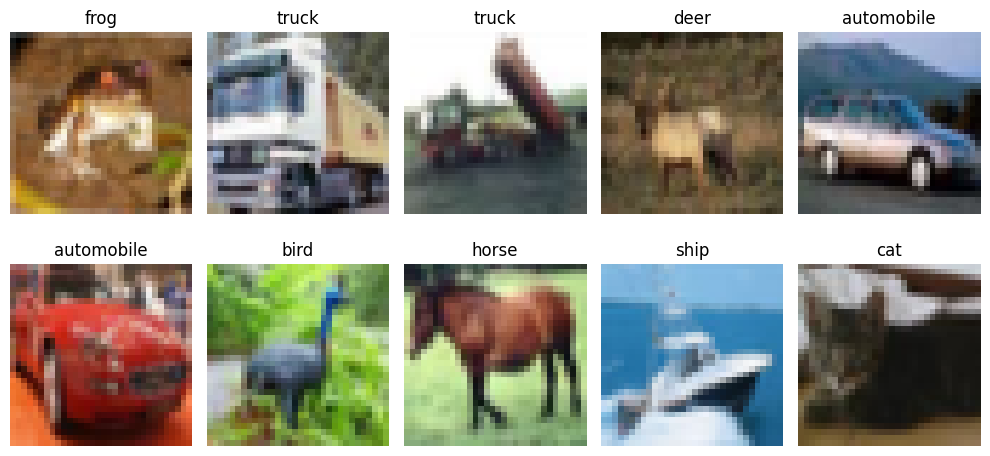

Resizing images to 96x96...


I0000 00:00:1778174819.856990      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Train ResNet data ready.
Test ResNet data ready.

APPROACH 1: ResNet50 + SVM
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Extracting features...


I0000 00:00:1778174861.467098     137 service.cc:152] XLA service 0x7fc0f8002530 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778174861.467157     137 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1778174862.250137     137 cuda_dnn.cc:529] Loaded cuDNN version 91002


   8/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step

I0000 00:00:1778174864.760090     137 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step
Train Features Shape: (50000, 2048)
Test Features Shape: (10000, 2048)

[SVM] Using 10000 / 50000 samples (20%) for training.

Training SVM...

===== SVM RESULTS =====
Accuracy : 0.8256
Precision: 0.8273
Recall   : 0.8256
F1-Score : 0.8261

Classification Report:

              precision    recall  f1-score   support

    airplane       0.82      0.88      0.85      1000
  automobile       0.90      0.88      0.89      1000
        bird       0.78      0.83      0.80      1000
         cat       0.68      0.71      0.69      1000
        deer       0.79      0.78      0.78      1000
         dog       0.77      0.74      0.76      1000
        frog       0.88      0.86      0.87      1000
       horse       0.88      0.82      0.85      1000
        ship       0.90      0.90      0.90      1000
       truck       0.87      0.87      0.87      1000

    accuracy                           0.83     1000

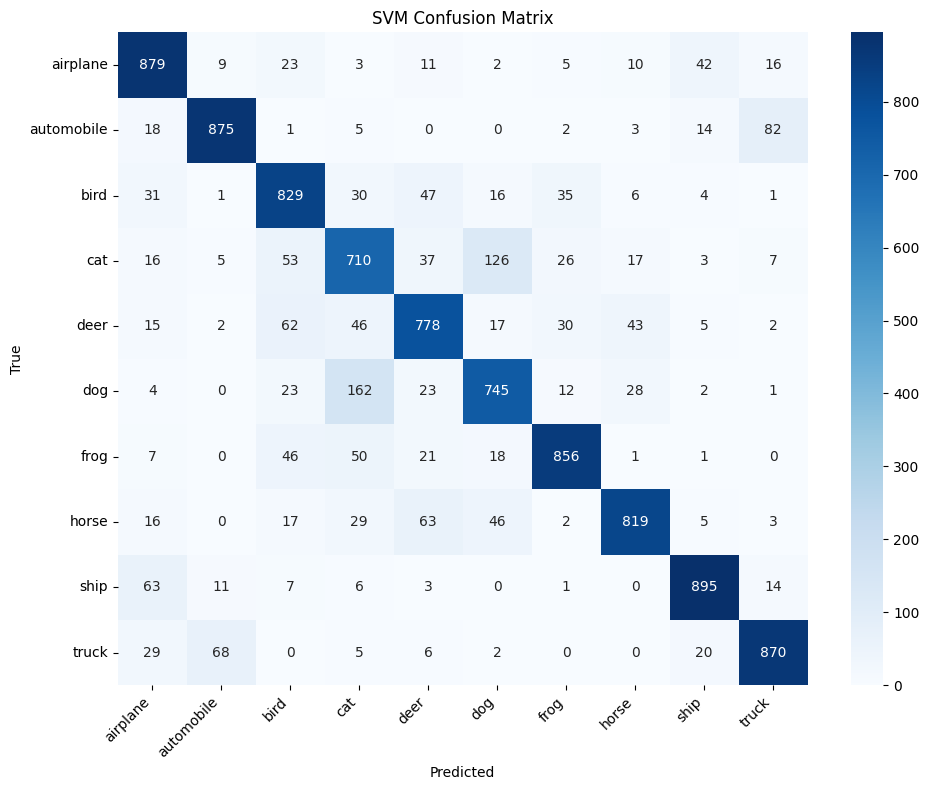

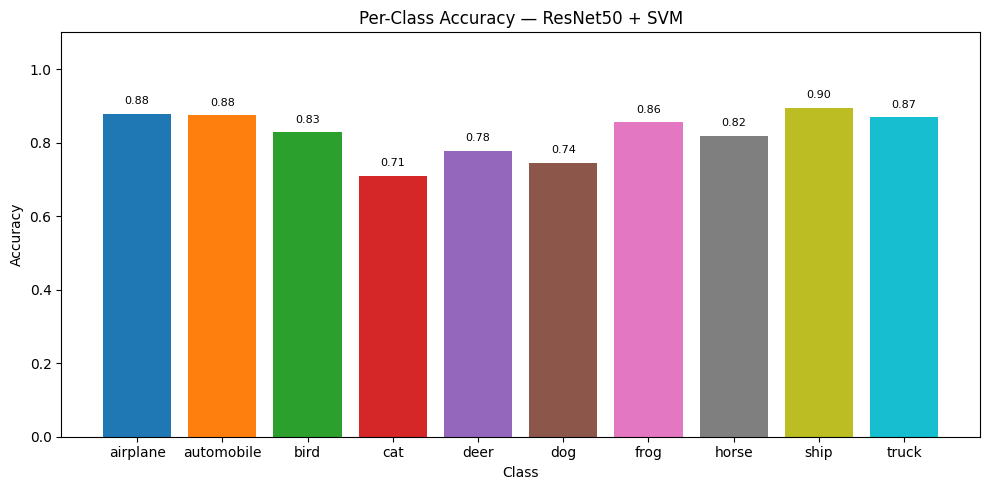


APPROACH 2: End-to-End ResNet50


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 3, 3, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,123,018 (92.02 MB)

 Trainable params: 531,210 (2.03 MB)

 Non-trainable params: 23,591,808 (90.00 MB)


--- Phase 1: Training with frozen ResNet50 base ---
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.5292 - loss: 1.7043
Epoch 1: val_accuracy improved from -inf to 0.82300, saving model to /kaggle/working/best_resnet50_phase1.keras
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 147s 86ms/step - accuracy: 0.5293 - loss: 1.7039 - val_accuracy: 0.8230 - val_loss: 0.5146 - learning_rate: 1.0000e-04
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.7329 - loss: 0.8325
Epoch 2: val_accuracy improved from 0.82300 to 0.83890, saving model to /kaggle/working/best_resnet50_phase1.keras
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 121s 77ms/step - accuracy: 0.7329 - loss: 0.8325 - val_accuracy: 0.8389 - val_loss: 0.4621 - learning_rate: 1.0000e-04
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.7521 - loss: 0.7538
Epoch 3: val_accuracy improved from 0.83890 to 0.84540, saving model to /kaggle/working/best_resnet50_phase1.keras
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 120s 77ms/step - accuracy: 0.7521 - loss: 0.7538 - val_accuracy: 0.8454 -

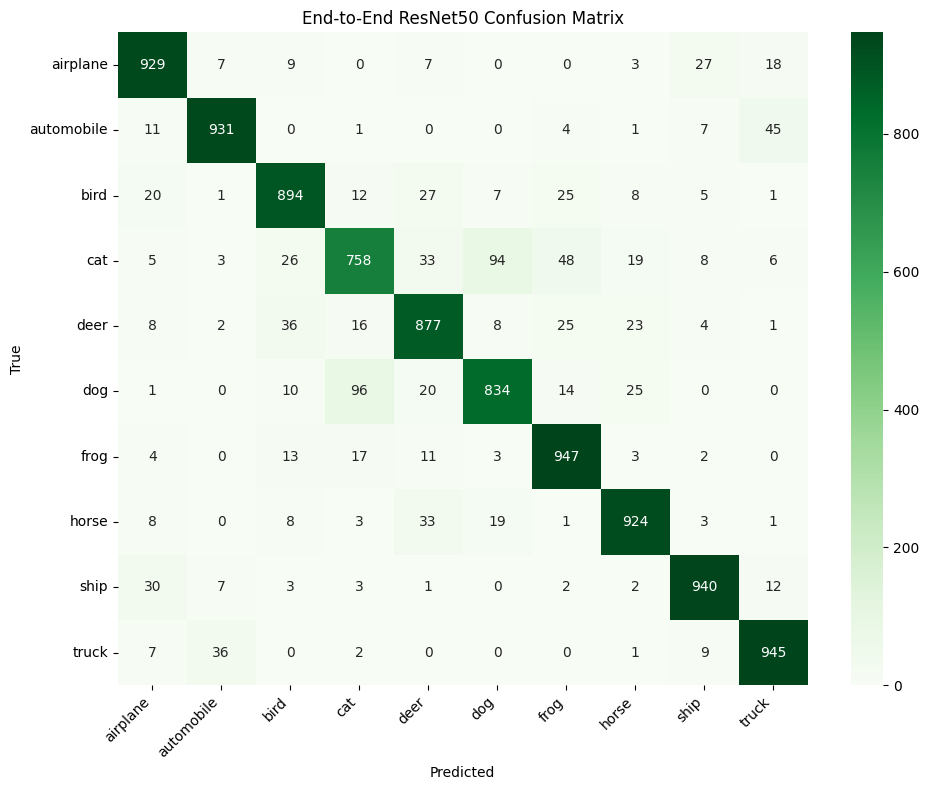

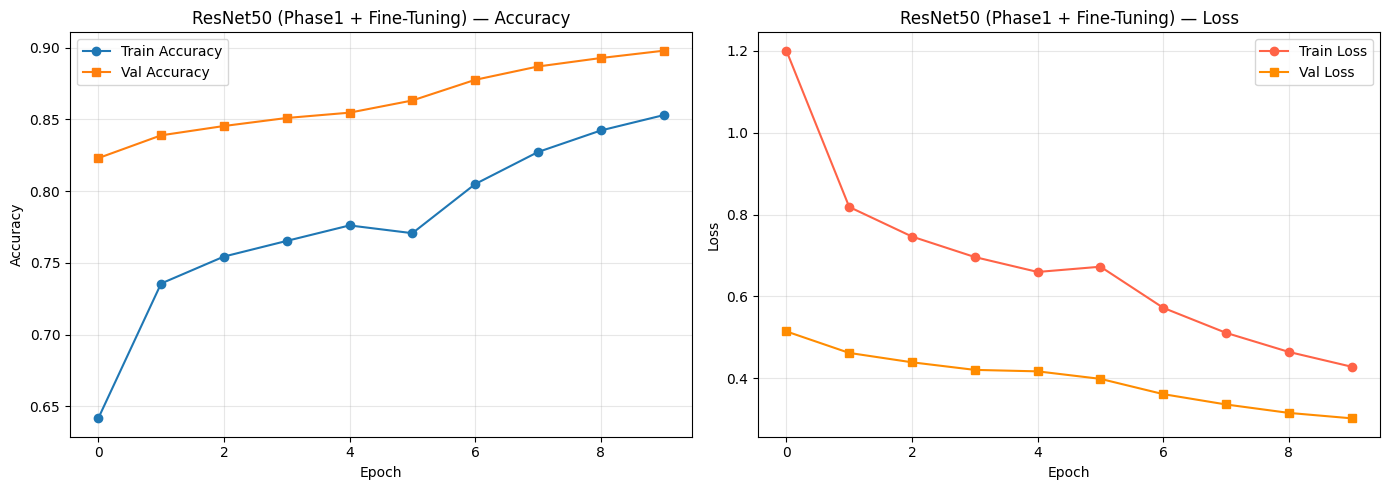

Fine-tuning started at epoch 6


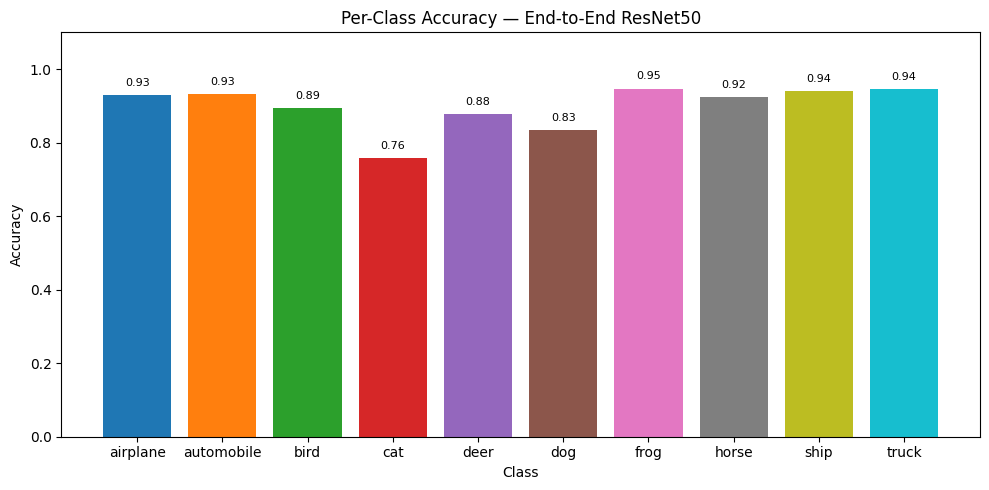


BONUS MODEL: MobileNetV2
Freed ResNet arrays. Re-resizing for MobileNetV2...
MobileNetV2 data ready.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5991 - loss: 1.2382
Epoch 1: val_accuracy improved from -inf to 0.83290, saving model to /kaggle/working/best_mobilenetv2.keras
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 40s 19ms/step - accuracy: 0.5992 - loss: 1.2379 - val_accuracy: 0.8329 - val_loss: 0.4861 - learning_rate: 1.0000e-04
Epoch 2/5
1559/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8180 - loss: 0.5448
Epoch 2: val_accuracy improved from 0.83290 to 0.84710, saving model to /kaggle/working/best_mobilenetv2.keras
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.8181 - loss: 0.5448 - val_accuracy: 0.8471 - val_loss: 0.4389 - learning_rate: 1.0000e-04
Epoch 3/5
1560/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8404 - loss: 0.4706
Epoch 3: val_accuracy improved from 0.84710 to 0.85810, saving model t

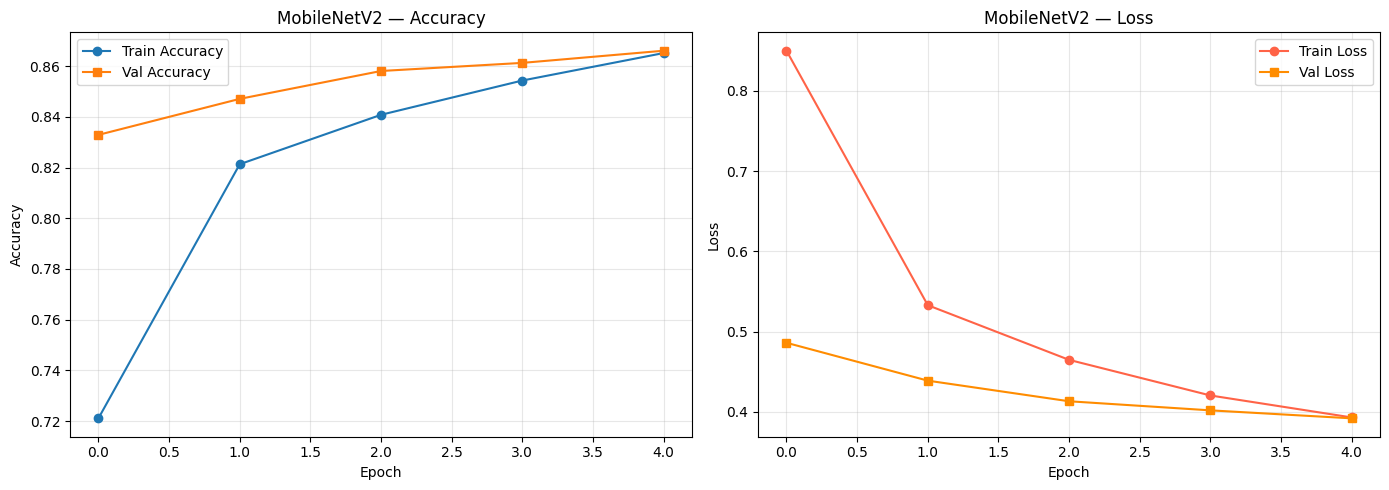

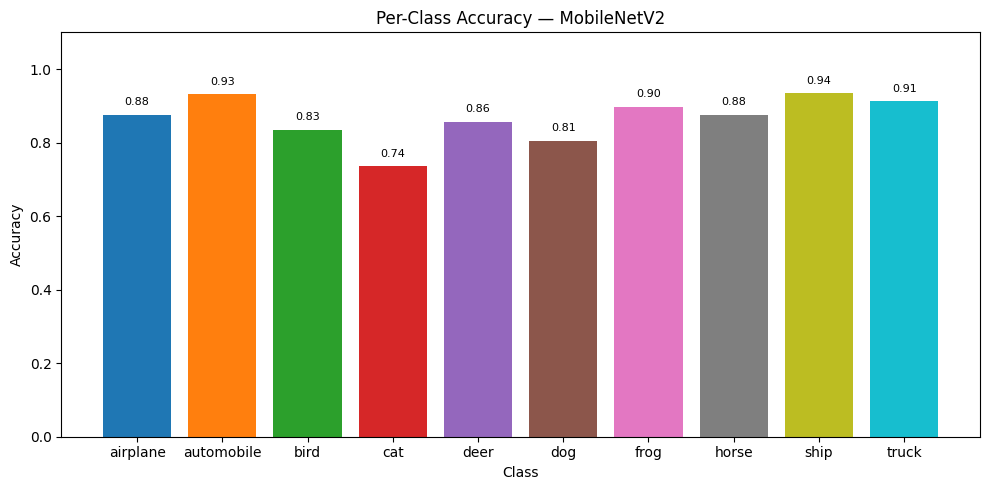

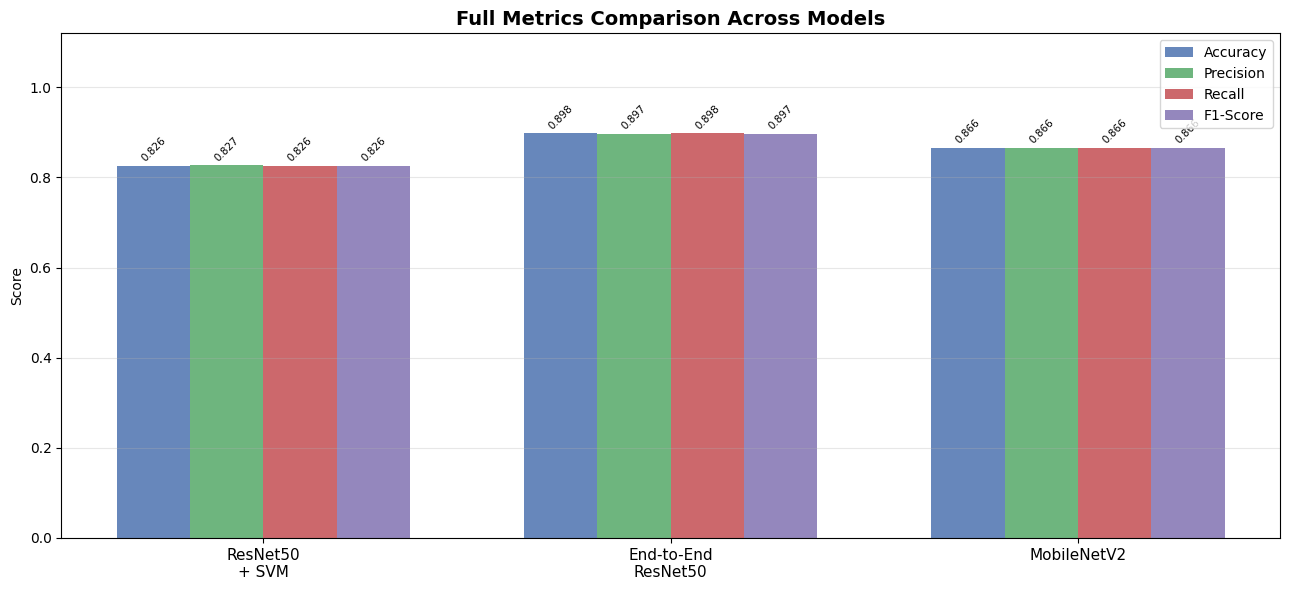


FINAL COMPARISON
Model                           Accuracy  Precision   Recall       F1
---------------------------------------------------------------------
ResNet50 + SVM                    0.8256     0.8273   0.8256   0.8261
End-to-End ResNet50               0.8979     0.8972   0.8979   0.8972
MobileNetV2                       0.8661     0.8658   0.8661   0.8658

Project Completed Successfully.


In [1]:
# =========================================================
# Deep Learning Project
# CIFAR-10 Classification
# Approach 1:
#   ResNet50 Feature Extractor + SVM
#
# Approach 2:
#   End-to-End ResNet50 (with Fine-Tuning phase)
#
# Bonus:
#   Extra CNN Model = MobileNetV2
#
# Modifications Added:
#   - SVM subset sampling (faster training)
#   - EarlyStopping + ReduceLROnPlateau callbacks
#   - Fine-Tuning phase for ResNet50 (last 30 layers)
#   - Loss curves alongside accuracy curves
#   - Full metrics comparison chart (Acc/Prec/Recall/F1)
#   - Model checkpointing (best weights)
#   - Per-class accuracy bar charts
#
# Platform:
#   Google Colab / Kaggle
# =========================================================

# =========================================================
# INSTALL / IMPORT LIBRARIES
# =========================================================

import os
import gc

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import ResNet50, MobileNetV2
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobile_preprocess

from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.preprocessing import StandardScaler

print("TensorFlow Version:", tf.__version__)

# =========================================================
# CONFIGURATION
# =========================================================

# --- Kaggle / Colab auto-detection ---
# On Kaggle, outputs must go to /kaggle/working/
# On Colab or local, outputs go to the current directory.
if os.path.exists('/kaggle/working'):
    OUTPUT_DIR = '/kaggle/working/'
    print("Running on Kaggle — outputs will be saved to /kaggle/working/")
else:
    OUTPUT_DIR = './'
    print("Running on Colab / Local — outputs will be saved to current directory")

# [MODIFICATION] Fraction of training data used for SVM
# (1.0 = full 50k samples, 0.2 = 10k samples for speed)
SVM_SAMPLE_FRACTION = 0.2

# [OOM FIX] Reduced from 224 to 96 to fit in Kaggle's 13 GB RAM.
# Memory usage: 96x96 = ~2.5 GB vs 224x224 = ~36 GB for 60k images.
# ResNet50/MobileNetV2 work well from 32x32 upwards.
IMG_SIZE = 96
EPOCHS_PHASE1 = 5   # frozen base
EPOCHS_PHASE2 = 5   # fine-tuning (ResNet50 only)
BATCH_SIZE = 32

class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# =========================================================
# LOAD CIFAR-10 DATASET
# =========================================================

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Training Images:", x_train.shape)
print("Testing Images:", x_test.shape)

# =========================================================
# VISUALIZE SAMPLE IMAGES
# =========================================================

plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'sample_images.png'), dpi=100, bbox_inches='tight')
plt.show()

# =========================================================
# RESIZE IMAGES FOR PRETRAINED CNNs
# =========================================================

def resize_images(images):
    resized = tf.image.resize(images, (IMG_SIZE, IMG_SIZE))
    return resized.numpy()

print(f"Resizing images to {IMG_SIZE}x{IMG_SIZE}...")

# =========================================================
# NORMALIZATION + MEMORY-EFFICIENT LOADING
# [OOM FIX] Resize → preprocess → immediately delete the raw
# resized array so we never hold two full float32 copies at once.
# =========================================================

x_train_resnet = resnet_preprocess(resize_images(x_train))
print("Train ResNet data ready.")
gc.collect()

x_test_resnet = resnet_preprocess(resize_images(x_test))
print("Test ResNet data ready.")
gc.collect()

# =========================================================
# DATA AUGMENTATION
# =========================================================

train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)
train_datagen.fit(x_train_resnet)

# =========================================================
# ONE HOT ENCODING
# =========================================================

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)


# =========================================================
# HELPER: Plot Training Curves (Accuracy + Loss)
# =========================================================

def plot_training_curves(history, title_prefix, save_name):
    """[MODIFICATION] Plot both accuracy and loss curves side by side."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    axes[0].plot(history.history['accuracy'], label='Train Accuracy', marker='o')
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', marker='s')
    axes[0].set_title(f"{title_prefix} — Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Loss
    axes[1].plot(history.history['loss'], label='Train Loss', marker='o', color='tomato')
    axes[1].plot(history.history['val_loss'], label='Val Loss', marker='s', color='darkorange')
    axes[1].set_title(f"{title_prefix} — Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, save_name), dpi=100, bbox_inches='tight')
    plt.show()


# =========================================================
# HELPER: Per-Class Accuracy Bar Chart
# =========================================================

def plot_per_class_accuracy(y_true, y_pred, model_name, save_name):
    """[MODIFICATION] Bar chart of per-class accuracy for each model."""
    cm = confusion_matrix(y_true, y_pred)
    per_class_acc = cm.diagonal() / cm.sum(axis=1)

    plt.figure(figsize=(10, 5))
    bars = plt.bar(class_names, per_class_acc, color=plt.cm.tab10.colors)
    plt.title(f"Per-Class Accuracy — {model_name}")
    plt.xlabel("Class")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1.1)
    for bar, acc in zip(bars, per_class_acc):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f"{acc:.2f}",
            ha='center', va='bottom', fontsize=8
        )
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, save_name), dpi=100, bbox_inches='tight')
    plt.show()


# =========================================================
# =========================================================
# APPROACH 1
# FEATURE EXTRACTION + SVM
# =========================================================
# =========================================================

print("\n==============================")
print("APPROACH 1: ResNet50 + SVM")
print("==============================")

# =========================================================
# LOAD PRETRAINED RESNET50 (Feature Extractor)
# =========================================================

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

x = GlobalAveragePooling2D()(base_model.output)
feature_extractor = Model(inputs=base_model.input, outputs=x)
feature_extractor.trainable = False

print("Extracting features...")

# =========================================================
# FEATURE EXTRACTION
# =========================================================

train_features = feature_extractor.predict(x_train_resnet, batch_size=BATCH_SIZE, verbose=1)
test_features = feature_extractor.predict(x_test_resnet, batch_size=BATCH_SIZE, verbose=1)

print("Train Features Shape:", train_features.shape)
print("Test Features Shape:", test_features.shape)

# =========================================================
# FEATURE SCALING
# =========================================================

scaler = StandardScaler()
train_features_scaled = scaler.fit_transform(train_features)
test_features_scaled = scaler.transform(test_features)

# =========================================================
# [MODIFICATION] SUBSET SAMPLING FOR SVM
# Training SVM on all 50k samples is very slow.
# We randomly sample SVM_SAMPLE_FRACTION of the training set.
# =========================================================

np.random.seed(42)
n_samples = int(len(train_features_scaled) * SVM_SAMPLE_FRACTION)
subset_idx = np.random.choice(len(train_features_scaled), n_samples, replace=False)

train_features_svm = train_features_scaled[subset_idx]
y_train_svm = y_train.ravel()[subset_idx]

print(f"\n[SVM] Using {n_samples} / {len(train_features_scaled)} samples "
      f"({SVM_SAMPLE_FRACTION*100:.0f}%) for training.")

# =========================================================
# TRAIN SVM
# =========================================================

print("\nTraining SVM...")
svm_model = SVC(kernel='linear', probability=True)
svm_model.fit(train_features_svm, y_train_svm)

# =========================================================
# PREDICTIONS & EVALUATION
# =========================================================

svm_predictions = svm_model.predict(test_features_scaled)

svm_accuracy  = accuracy_score(y_test, svm_predictions)
svm_precision = precision_score(y_test, svm_predictions, average='weighted')
svm_recall    = recall_score(y_test, svm_predictions, average='weighted')
svm_f1        = f1_score(y_test, svm_predictions, average='weighted')

print("\n===== SVM RESULTS =====")
print(f"Accuracy : {svm_accuracy:.4f}")
print(f"Precision: {svm_precision:.4f}")
print(f"Recall   : {svm_recall:.4f}")
print(f"F1-Score : {svm_f1:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, svm_predictions, target_names=class_names))

# Confusion Matrix
cm_svm = confusion_matrix(y_test, svm_predictions)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'svm_confusion_matrix.png'), dpi=100, bbox_inches='tight')
plt.show()

# [MODIFICATION] Per-class accuracy chart
plot_per_class_accuracy(y_test, svm_predictions, "ResNet50 + SVM", "svm_per_class.png")


# =========================================================
# =========================================================
# APPROACH 2
# END-TO-END RESNET50  (Phase 1: Frozen + Phase 2: Fine-Tuning)
# =========================================================
# =========================================================

print("\n==============================")
print("APPROACH 2: End-to-End ResNet50")
print("==============================")

# =========================================================
# BUILD MODEL
# =========================================================

base_model2 = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model2.trainable = False

model = Sequential([
    base_model2,
    GlobalAveragePooling2D(),
    BatchNormalization(),          # [MODIFICATION] BN before dense
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

# =========================================================
# [MODIFICATION] CALLBACKS
# =========================================================

callbacks_phase1 = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        os.path.join(OUTPUT_DIR, 'best_resnet50_phase1.keras'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# =========================================================
# PHASE 1: TRAIN WITH FROZEN BASE
# =========================================================

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

print("\n--- Phase 1: Training with frozen ResNet50 base ---")
history_p1 = model.fit(
    train_datagen.flow(x_train_resnet, y_train_cat, batch_size=BATCH_SIZE),
    validation_data=(x_test_resnet, y_test_cat),
    epochs=EPOCHS_PHASE1,
    callbacks=callbacks_phase1
)

# =========================================================
# [MODIFICATION] PHASE 2: FINE-TUNING
# Unfreeze the last 30 layers of ResNet50 and train with
# a much lower learning rate.
# =========================================================

print("\n--- Phase 2: Fine-Tuning last 30 layers of ResNet50 ---")

base_model2.trainable = True
for layer in base_model2.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),   # very low LR for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_phase2 = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-8,
        verbose=1
    ),
    ModelCheckpoint(
        os.path.join(OUTPUT_DIR, 'best_resnet50_finetuned.keras'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

history_p2 = model.fit(
    train_datagen.flow(x_train_resnet, y_train_cat, batch_size=BATCH_SIZE),
    validation_data=(x_test_resnet, y_test_cat),
    epochs=EPOCHS_PHASE2,
    callbacks=callbacks_phase2
)

# =========================================================
# EVALUATION
# =========================================================

loss, accuracy = model.evaluate(x_test_resnet, y_test_cat)

predictions = model.predict(x_test_resnet)
predicted_classes = np.argmax(predictions, axis=1)

dl_precision = precision_score(y_test, predicted_classes, average='weighted')
dl_recall    = recall_score(y_test, predicted_classes, average='weighted')
dl_f1        = f1_score(y_test, predicted_classes, average='weighted')

print("\n===== END-TO-END ResNet50 RESULTS =====")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Precision    : {dl_precision:.4f}")
print(f"Recall       : {dl_recall:.4f}")
print(f"F1-Score     : {dl_f1:.4f}")

# Confusion Matrix
cm_dl = confusion_matrix(y_test, predicted_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_dl, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title("End-to-End ResNet50 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'resnet50_confusion_matrix.png'), dpi=100, bbox_inches='tight')
plt.show()

# [MODIFICATION] Combined training curves (Phase 1 + Phase 2)
def merge_histories(h1, h2):
    merged = {}
    for key in h1.history:
        merged[key] = h1.history[key] + h2.history[key]
    return type('History', (), {'history': merged})()

combined_history = merge_histories(history_p1, history_p2)
plot_training_curves(combined_history, "ResNet50 (Phase1 + Fine-Tuning)", "resnet50_curves.png")

# Add a vertical line to show where fine-tuning starts
epochs_p1 = len(history_p1.history['accuracy'])
print(f"Fine-tuning started at epoch {epochs_p1 + 1}")

# [MODIFICATION] Per-class accuracy chart
plot_per_class_accuracy(y_test, predicted_classes, "End-to-End ResNet50", "resnet50_per_class.png")


# =========================================================
# BONUS MODEL
# MobileNetV2
# =========================================================

print("\n==============================")
print("BONUS MODEL: MobileNetV2")
print("==============================")

# [OOM FIX] Free the ResNet preprocessed arrays before creating
# MobileNetV2 data — we re-resize from the original uint8 x_train
# (only ~150 MB) so peak memory stays low.
del x_train_resnet, x_test_resnet
gc.collect()
print("Freed ResNet arrays. Re-resizing for MobileNetV2...")

x_train_mobile = mobile_preprocess(resize_images(x_train))
gc.collect()
x_test_mobile = mobile_preprocess(resize_images(x_test))
gc.collect()
print("MobileNetV2 data ready.")

mobile_base = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
mobile_base.trainable = False

mobile_model = Sequential([
    mobile_base,
    GlobalAveragePooling2D(),
    BatchNormalization(),           # [MODIFICATION] BN added
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

mobile_model.compile(
    optimizer=Adam(0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# [MODIFICATION] Callbacks for MobileNetV2
callbacks_mobile = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        os.path.join(OUTPUT_DIR, 'best_mobilenetv2.keras'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

mobile_history = mobile_model.fit(
    x_train_mobile,
    y_train_cat,
    validation_data=(x_test_mobile, y_test_cat),
    epochs=EPOCHS_PHASE1,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_mobile
)

mobile_loss, mobile_acc = mobile_model.evaluate(x_test_mobile, y_test_cat)

mobile_preds = np.argmax(mobile_model.predict(x_test_mobile), axis=1)
mob_precision = precision_score(y_test, mobile_preds, average='weighted')
mob_recall    = recall_score(y_test, mobile_preds, average='weighted')
mob_f1        = f1_score(y_test, mobile_preds, average='weighted')

print("\n===== MobileNetV2 RESULTS =====")
print(f"Accuracy : {mobile_acc:.4f}")
print(f"Precision: {mob_precision:.4f}")
print(f"Recall   : {mob_recall:.4f}")
print(f"F1-Score : {mob_f1:.4f}")

# [MODIFICATION] Training curves for MobileNetV2
plot_training_curves(mobile_history, "MobileNetV2", "mobilenet_curves.png")

# [MODIFICATION] Per-class accuracy chart
plot_per_class_accuracy(y_test, mobile_preds, "MobileNetV2", "mobilenet_per_class.png")


# =========================================================
# [MODIFICATION] FULL METRICS COMPARISON CHART
# Shows Accuracy, Precision, Recall, F1 side by side
# =========================================================

model_names = ['ResNet50\n+ SVM', 'End-to-End\nResNet50', 'MobileNetV2']

metrics = {
    'Accuracy' : [svm_accuracy,  accuracy,     mobile_acc],
    'Precision': [svm_precision, dl_precision, mob_precision],
    'Recall'   : [svm_recall,    dl_recall,    mob_recall],
    'F1-Score' : [svm_f1,        dl_f1,        mob_f1],
}

x_pos = np.arange(len(model_names))
width = 0.18
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

fig, ax = plt.subplots(figsize=(13, 6))

for i, (metric_name, values) in enumerate(metrics.items()):
    offset = (i - 1.5) * width
    bars = ax.bar(x_pos + offset, values, width, label=metric_name, color=colors[i], alpha=0.85)
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{val:.3f}",
            ha='center', va='bottom', fontsize=7.5, rotation=45
        )

ax.set_xticks(x_pos)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.12)
ax.set_title("Full Metrics Comparison Across Models", fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'full_metrics_comparison.png'), dpi=100, bbox_inches='tight')
plt.show()


# =========================================================
# FINAL SUMMARY
# =========================================================

print("\n" + "="*50)
print("FINAL COMPARISON")
print("="*50)

header = f"{'Model':<30} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8}"
print(header)
print("-" * len(header))
print(f"{'ResNet50 + SVM':<30} {svm_accuracy:>9.4f} {svm_precision:>10.4f} {svm_recall:>8.4f} {svm_f1:>8.4f}")
print(f"{'End-to-End ResNet50':<30} {accuracy:>9.4f} {dl_precision:>10.4f} {dl_recall:>8.4f} {dl_f1:>8.4f}")
print(f"{'MobileNetV2':<30} {mobile_acc:>9.4f} {mob_precision:>10.4f} {mob_recall:>8.4f} {mob_f1:>8.4f}")

print("\nProject Completed Successfully.")


Loading model from: /kaggle/working/best_resnet50_finetuned.keras
Model loaded successfully.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 3, 3, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,085,792 (206.32 MB)

 Trainable params: 14,981,386 (57.15 MB)

 Non-trainable params: 9,141,632 (34.87 MB)

 Optimizer params: 29,962,774 (114.30 MB)


Loading CIFAR-10 test set...
CIFAR-10 test shape after preprocessing: (10000, 96, 96, 3)

Evaluating on CIFAR-10 original test set...
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step

===== ResNet50 on CIFAR-10 (Original Test Set) =====
Accuracy : 0.8979
Precision: 0.8972
Recall   : 0.8979
F1-Score : 0.8972

Download complete.

CIFAR-10.1 images : (2000, 32, 32, 3)   dtype=uint8
CIFAR-10.1 labels : (2000,)   unique=[0 1 2 3 4 5 6 7 8 9]
Samples per class : [200 200 200 200 200 200 200 200 200 200]


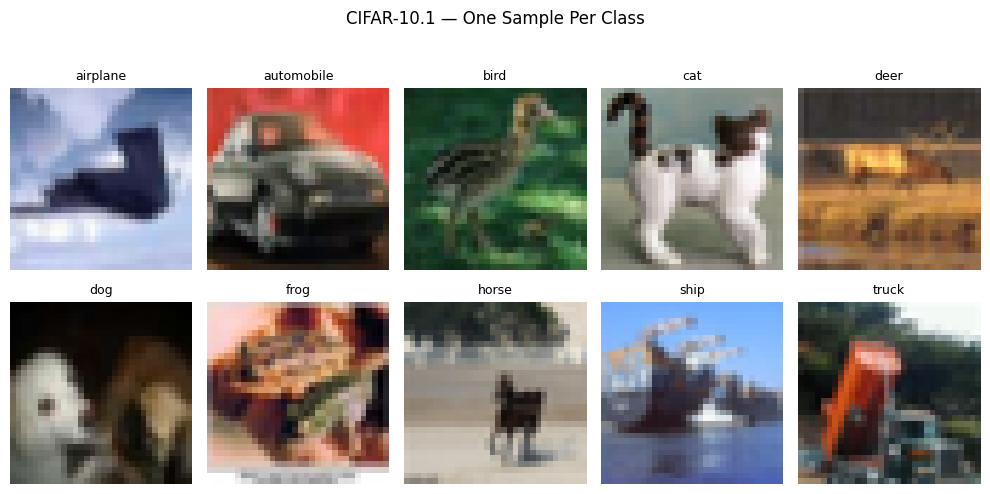


Preprocessing CIFAR-10.1...
Shape after resize+preprocess: (2000, 96, 96, 3)

Running predictions on CIFAR-10.1...
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step

===== ResNet50 on CIFAR-10.1 =====
Accuracy : 0.8005
Precision: 0.8054
Recall   : 0.8005
F1-Score : 0.7992

Classification Report:

              precision    recall  f1-score   support

    airplane       0.80      0.76      0.78       200
  automobile       0.93      0.74      0.82       200
        bird       0.84      0.79      0.82       200
         cat       0.76      0.64      0.69       200
        deer       0.80      0.80      0.80       200
         dog       0.83      0.75      0.79       200
        frog       0.74      0.91      0.82       200
       horse       0.79      0.86      0.83       200
        ship       0.82      0.85      0.84       200
       truck       0.75      0.91      0.82       200

    accuracy                           0.80      2000
   macro avg       0.81      0.80      0.80      2000
weighte

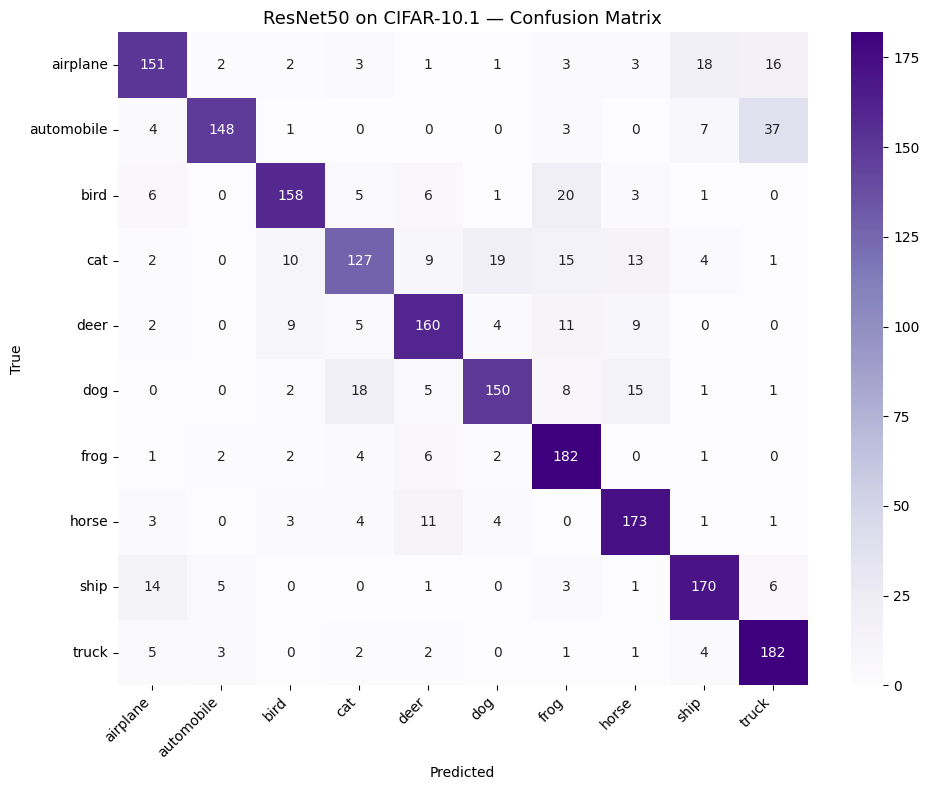

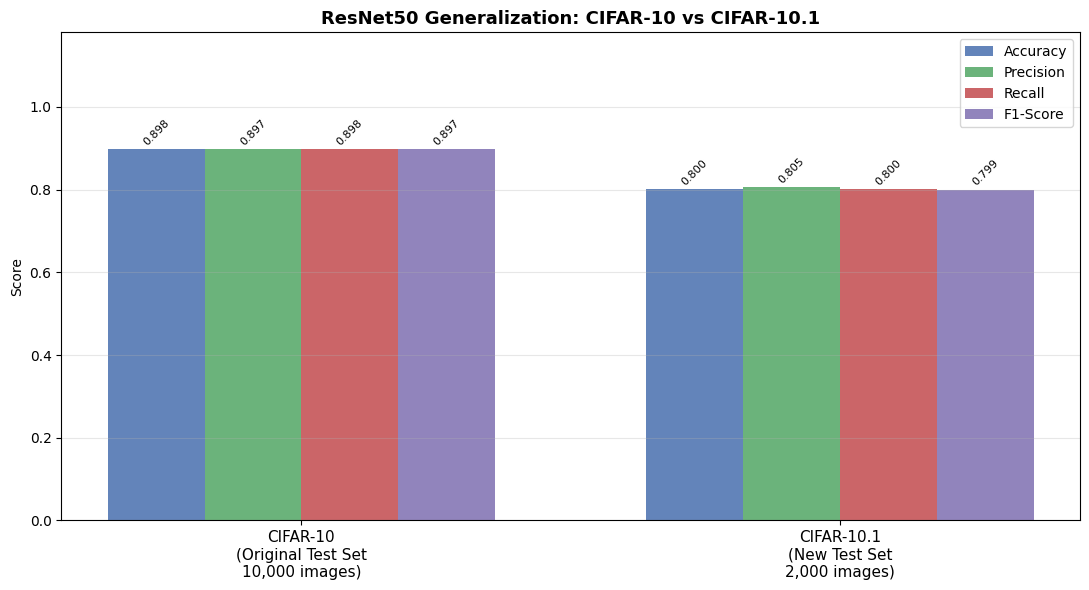

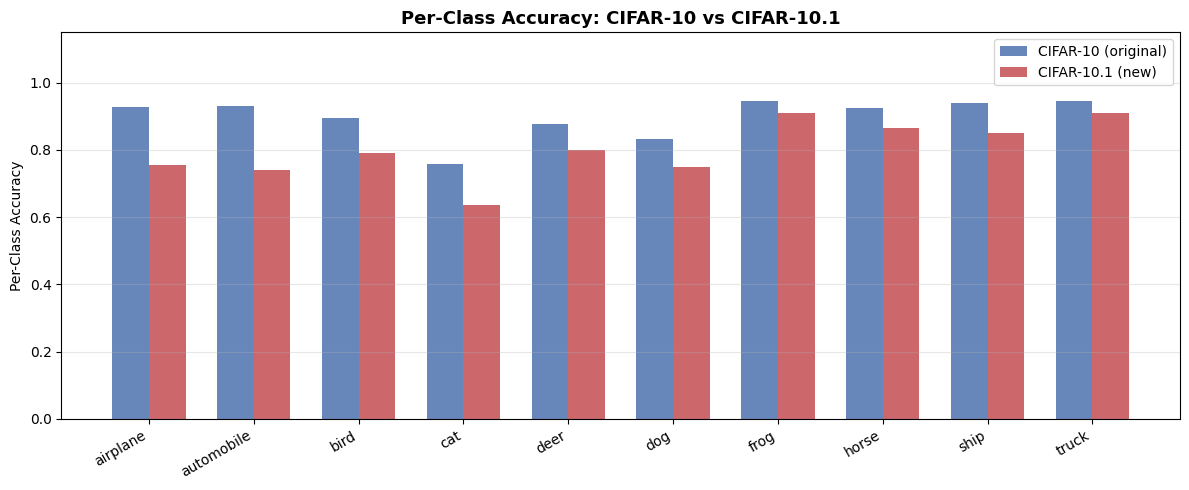


GENERALIZATION SUMMARY
Metric           CIFAR-10   CIFAR-10.1     Drop
----------------------------------------------------
Accuracy           0.8979       0.8005  +0.0974
Precision          0.8972       0.8054  +0.0918
Recall             0.8979       0.8005  +0.0974
F1-Score           0.8972       0.7992  +0.0980

⚠  Accuracy dropped by 9.7% on CIFAR-10.1.
   The model is sensitive to distribution shift.


In [2]:
# =========================================================
# EXTRA DATASET
# Evaluate End-to-End ResNet50 on CIFAR-10.1
# =========================================================
# CIFAR-10.1 is a new harder test set for CIFAR-10.
# Same 10 classes, 2,000 images, designed specifically to
# measure distribution shift / generalization of models
# trained on the original CIFAR-10 dataset.
#
# Source: https://github.com/modestyachts/CIFAR-10.1
#
# *** FULLY SELF-CONTAINED CELL ***
# Loads the saved model from disk — no variables needed
# from the main script. Safe to run after kernel restart.
# =========================================================

import urllib.request
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import tensorflow as tf

from tensorflow.keras.models import load_model
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# =========================================================
# CONFIG  (must match the values used in the main script)
# =========================================================

OUTPUT_DIR = '/kaggle/working/' if os.path.exists('/kaggle/working') else './'
IMG_SIZE   = 96    # change this if you used a different size
BATCH_SIZE = 32

class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

def resize_images(images):
    resized = tf.image.resize(images, (IMG_SIZE, IMG_SIZE))
    return resized.numpy()

# =========================================================
# LOAD SAVED MODEL FROM DISK
# =========================================================

MODEL_PATH = os.path.join(OUTPUT_DIR, 'best_resnet50_finetuned.keras')

# Fallback: if fine-tuned model doesn't exist, try phase-1 checkpoint
if not os.path.exists(MODEL_PATH):
    MODEL_PATH = os.path.join(OUTPUT_DIR, 'best_resnet50_phase1.keras')

print(f"Loading model from: {MODEL_PATH}")
model = load_model(MODEL_PATH)
print("Model loaded successfully.")
model.summary()

# =========================================================
# RELOAD CIFAR-10 TEST SET
# (needed to compare against CIFAR-10.1 performance)
# =========================================================

print("\nLoading CIFAR-10 test set...")
(_, _), (x_test_raw, y_test) = cifar10.load_data()

x_test_resnet = resnet_preprocess(resize_images(x_test_raw))
print(f"CIFAR-10 test shape after preprocessing: {x_test_resnet.shape}")

# =========================================================
# RE-EVALUATE MODEL ON CIFAR-10 (original test set)
# =========================================================

print("\nEvaluating on CIFAR-10 original test set...")
orig_preds_raw    = model.predict(x_test_resnet, batch_size=BATCH_SIZE, verbose=1)
predicted_classes = np.argmax(orig_preds_raw, axis=1)

accuracy     = accuracy_score(y_test, predicted_classes)
dl_precision = precision_score(y_test, predicted_classes, average='weighted')
dl_recall    = recall_score(y_test, predicted_classes, average='weighted')
dl_f1        = f1_score(y_test, predicted_classes, average='weighted')

print("\n===== ResNet50 on CIFAR-10 (Original Test Set) =====")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {dl_precision:.4f}")
print(f"Recall   : {dl_recall:.4f}")
print(f"F1-Score : {dl_f1:.4f}")

# =========================================================
# DOWNLOAD CIFAR-10.1
# =========================================================

BASE_URL    = "https://github.com/modestyachts/CIFAR-10.1/raw/master/datasets/"
DATA_FILE   = os.path.join(OUTPUT_DIR, "cifar10_1_data.npy")
LABELS_FILE = os.path.join(OUTPUT_DIR, "cifar10_1_labels.npy")

print("\nDownloading CIFAR-10.1 dataset...")
urllib.request.urlretrieve(BASE_URL + "cifar10.1_v6_data.npy",   DATA_FILE)
urllib.request.urlretrieve(BASE_URL + "cifar10.1_v6_labels.npy", LABELS_FILE)
print("Download complete.")

# =========================================================
# LOAD + INSPECT CIFAR-10.1
# =========================================================

x_extra = np.load(DATA_FILE)    # (2000, 32, 32, 3)  uint8
y_extra = np.load(LABELS_FILE)  # (2000,)             int64

print(f"\nCIFAR-10.1 images : {x_extra.shape}   dtype={x_extra.dtype}")
print(f"CIFAR-10.1 labels : {y_extra.shape}   unique={np.unique(y_extra)}")
print(f"Samples per class : {np.bincount(y_extra)}")

# =========================================================
# VISUALIZE CIFAR-10.1 SAMPLES
# =========================================================

plt.figure(figsize=(10, 5))
for i in range(10):
    idx = np.where(y_extra == i)[0][0]
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_extra[idx])
    plt.title(class_names[i], fontsize=9)
    plt.axis('off')
plt.suptitle("CIFAR-10.1 — One Sample Per Class", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'cifar101_samples.png'), dpi=100, bbox_inches='tight')
plt.show()

# =========================================================
# PREPROCESS CIFAR-10.1 (same pipeline as main script)
# =========================================================

print("\nPreprocessing CIFAR-10.1...")
x_extra_resnet = resnet_preprocess(resize_images(x_extra))
print(f"Shape after resize+preprocess: {x_extra_resnet.shape}")

# =========================================================
# EVALUATE ResNet50 ON CIFAR-10.1
# =========================================================

print("\nRunning predictions on CIFAR-10.1...")
extra_preds_raw = model.predict(x_extra_resnet, batch_size=BATCH_SIZE, verbose=1)
extra_preds     = np.argmax(extra_preds_raw, axis=1)

extra_accuracy  = accuracy_score(y_extra, extra_preds)
extra_precision = precision_score(y_extra, extra_preds, average='weighted')
extra_recall    = recall_score(y_extra, extra_preds, average='weighted')
extra_f1        = f1_score(y_extra, extra_preds, average='weighted')

print("\n===== ResNet50 on CIFAR-10.1 =====")
print(f"Accuracy : {extra_accuracy:.4f}")
print(f"Precision: {extra_precision:.4f}")
print(f"Recall   : {extra_recall:.4f}")
print(f"F1-Score : {extra_f1:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_extra, extra_preds, target_names=class_names))

# =========================================================
# CONFUSION MATRIX — CIFAR-10.1
# =========================================================

cm_extra = confusion_matrix(y_extra, extra_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_extra, annot=True, fmt='d', cmap='Purples',
    xticklabels=class_names, yticklabels=class_names
)
plt.title("ResNet50 on CIFAR-10.1 — Confusion Matrix", fontsize=13)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'cifar101_confusion_matrix.png'), dpi=100, bbox_inches='tight')
plt.show()

# =========================================================
# GENERALIZATION COMPARISON CHART
# CIFAR-10 original test set  vs  CIFAR-10.1 new test set
# =========================================================

labels = ['CIFAR-10\n(Original Test Set\n10,000 images)',
          'CIFAR-10.1\n(New Test Set\n2,000 images)']

metrics_compare = {
    'Accuracy' : [accuracy,     extra_accuracy],
    'Precision': [dl_precision, extra_precision],
    'Recall'   : [dl_recall,    extra_recall],
    'F1-Score' : [dl_f1,        extra_f1],
}

x_pos  = np.arange(len(labels))
width  = 0.18
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

fig, ax = plt.subplots(figsize=(11, 6))
for i, (metric_name, values) in enumerate(metrics_compare.items()):
    offset = (i - 1.5) * width
    bars = ax.bar(x_pos + offset, values, width,
                  label=metric_name, color=colors[i], alpha=0.87)
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{val:.3f}",
            ha='center', va='bottom', fontsize=8, rotation=45
        )

ax.set_xticks(x_pos)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.18)
ax.set_title("ResNet50 Generalization: CIFAR-10 vs CIFAR-10.1",
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'cifar10_vs_cifar101.png'), dpi=100, bbox_inches='tight')
plt.show()

# =========================================================
# PER-CLASS ACCURACY — side-by-side bar chart
# =========================================================

cm_orig       = confusion_matrix(y_test, predicted_classes)
orig_per_class  = cm_orig.diagonal()  / cm_orig.sum(axis=1)
extra_per_class = cm_extra.diagonal() / cm_extra.sum(axis=1)

x = np.arange(len(class_names))
w = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w/2, orig_per_class,  w, label='CIFAR-10 (original)', color='#4C72B0', alpha=0.85)
ax.bar(x + w/2, extra_per_class, w, label='CIFAR-10.1 (new)',    color='#C44E52', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=30, ha='right')
ax.set_ylabel("Per-Class Accuracy")
ax.set_ylim(0, 1.15)
ax.set_title("Per-Class Accuracy: CIFAR-10 vs CIFAR-10.1", fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'per_class_cifar10_vs_cifar101.png'), dpi=100, bbox_inches='tight')
plt.show()

# =========================================================
# FINAL SUMMARY TABLE
# =========================================================

drop = accuracy - extra_accuracy
print("\n" + "="*52)
print("GENERALIZATION SUMMARY")
print("="*52)
print(f"{'Metric':<12} {'CIFAR-10':>12} {'CIFAR-10.1':>12} {'Drop':>8}")
print("-" * 52)
print(f"{'Accuracy':<12} {accuracy:>12.4f} {extra_accuracy:>12.4f} {accuracy - extra_accuracy:>+8.4f}")
print(f"{'Precision':<12} {dl_precision:>12.4f} {extra_precision:>12.4f} {dl_precision - extra_precision:>+8.4f}")
print(f"{'Recall':<12} {dl_recall:>12.4f} {extra_recall:>12.4f} {dl_recall - extra_recall:>+8.4f}")
print(f"{'F1-Score':<12} {dl_f1:>12.4f} {extra_f1:>12.4f} {dl_f1 - extra_f1:>+8.4f}")
print("="*52)

if drop > 0.05:
    print(f"\n⚠  Accuracy dropped by {drop*100:.1f}% on CIFAR-10.1.")
    print("   The model is sensitive to distribution shift.")
elif drop > 0:
    print(f"\n✓  Minor accuracy drop of {drop*100:.1f}% — good generalization.")
else:
    print(f"\n✓  No drop detected — model generalizes well to CIFAR-10.1!")
